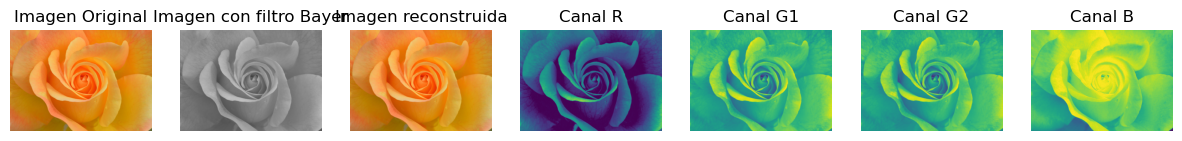

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("imagen4.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,30))

plt.subplot(1,7,1)
plt.imshow(img)
plt.title("Imagen Original")
plt.axis("off")

alto, ancho, canales = img.shape

bayer = np.zeros((alto, ancho), dtype=np.uint8)

for i in range(alto):
    for j in range(ancho):
        
        if i % 2 == 0 and j % 2 == 0:  
            bayer[i,j] = img[i,j,2] 

        elif i % 2 == 0 and j % 2 == 1:
            bayer[i,j] = img[i,j,1] 

        elif i % 2 == 1 and j % 2 == 0:
            bayer[i,j] = img[i,j,1] 

        else:
            bayer[i,j] = img[i,j,0] 

R  = bayer[0::2,0::2]
G1 = bayer[0::2,1::2]
G2 = bayer[1::2,0::2]
B  = bayer[1::2,1::2]

plt.subplot(1,7,2)
plt.imshow(bayer, cmap="gray")
plt.title("Imagen con filtro Bayer")
plt.axis("off")

reconstruida = cv2.cvtColor(bayer, cv2.COLOR_BAYER_RG2RGB)

plt.subplot(1,7,3)
plt.imshow(reconstruida)
plt.title("Imagen reconstruida")
plt.axis("off")

plt.subplot(1,7,4)
plt.imshow(R)
plt.title("Canal R")
plt.axis("off")

plt.subplot(1,7,5)
plt.imshow(G1)
plt.title("Canal G1")
plt.axis("off")

plt.subplot(1,7,6)
plt.imshow(G2)
plt.title("Canal G2")
plt.axis("off")

plt.subplot(1,7,7)
plt.imshow(B)
plt.title("Canal B")
plt.axis("off")
plt.show()


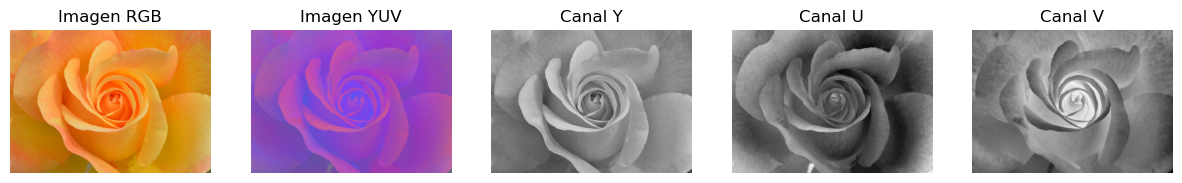

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread("imagen4.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_yuv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YUV)
np.save("imagen4_yuv.npy", img_yuv)
Y = img_yuv[:,:,0]
U = img_yuv[:,:,1]
V = img_yuv[:,:,2]

plt.figure(figsize=(15,4))

plt.subplot(1,5,1)
plt.imshow(img_rgb)
plt.title("Imagen RGB")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(img_yuv)
plt.title("Imagen YUV")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(Y, cmap="gray")
plt.title("Canal Y")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(U, cmap="gray")
plt.title("Canal U")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(V, cmap="gray")
plt.title("Canal V")
plt.axis("off")

plt.show()


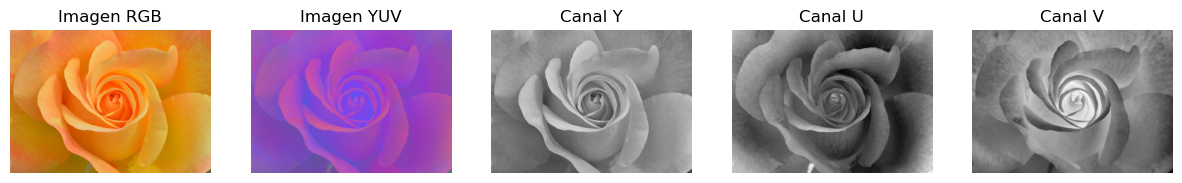

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("imagen4.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

Y = 0.299*R + 0.587*G + 0.114*B
U = -0.147*R -0.289*G + 0.436*B
V = 0.615*R -0.515*G -0.100*B

yuv = np.zeros_like(img_rgb, dtype=float)

yuv[:,:,0] = Y
yuv[:,:,1] = U
yuv[:,:,2] = V

plt.figure(figsize=(15,4))

plt.subplot(1,5,1)
plt.imshow(img_rgb)
plt.title("Imagen RGB")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(img_yuv)
plt.title("Imagen YUV")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(Y, cmap="gray")
plt.title("Canal Y")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(U, cmap="gray")
plt.title("Canal U")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(V, cmap="gray")
plt.title("Canal V")
plt.axis("off")

plt.show()


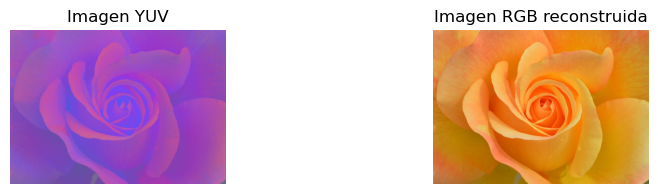

In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

yuv = np.load("imagen4_yuv.npy")

rgb = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(10,2))

plt.subplot(1,2,1)
plt.imshow(yuv)
plt.title("Imagen YUV")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb)
plt.title("Imagen RGB reconstruida")
plt.axis("off")
plt.show()
